# 🧠 Brain Tumor Detection 

### This Brain Tumor Detection project demonstrates the application of deep learning techniques in medical image analysis for identifying brain tumors.

In [18]:
# Importing the necessary libraries and Setup

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import plot_model
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
import pandas as pd
import cv2
from PIL import Image
import random
import json
import pickle
import gradio as gr

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Create directories if they don't exist
os.makedirs('models', exist_ok=True)
os.makedirs('training_history', exist_ok=True)
os.makedirs('evaluation', exist_ok=True)
os.makedirs('sample_images', exist_ok=True)

print("✅ All imports completed successfully!")
print("✅ Directories created: models/, training_history/, evaluation/, sample_images/")

✅ All imports completed successfully!
✅ Directories created: models/, training_history/, evaluation/, sample_images/


#### Dataset Analysis and Visualization

🔍 Analyzing dataset...
✅ Found classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


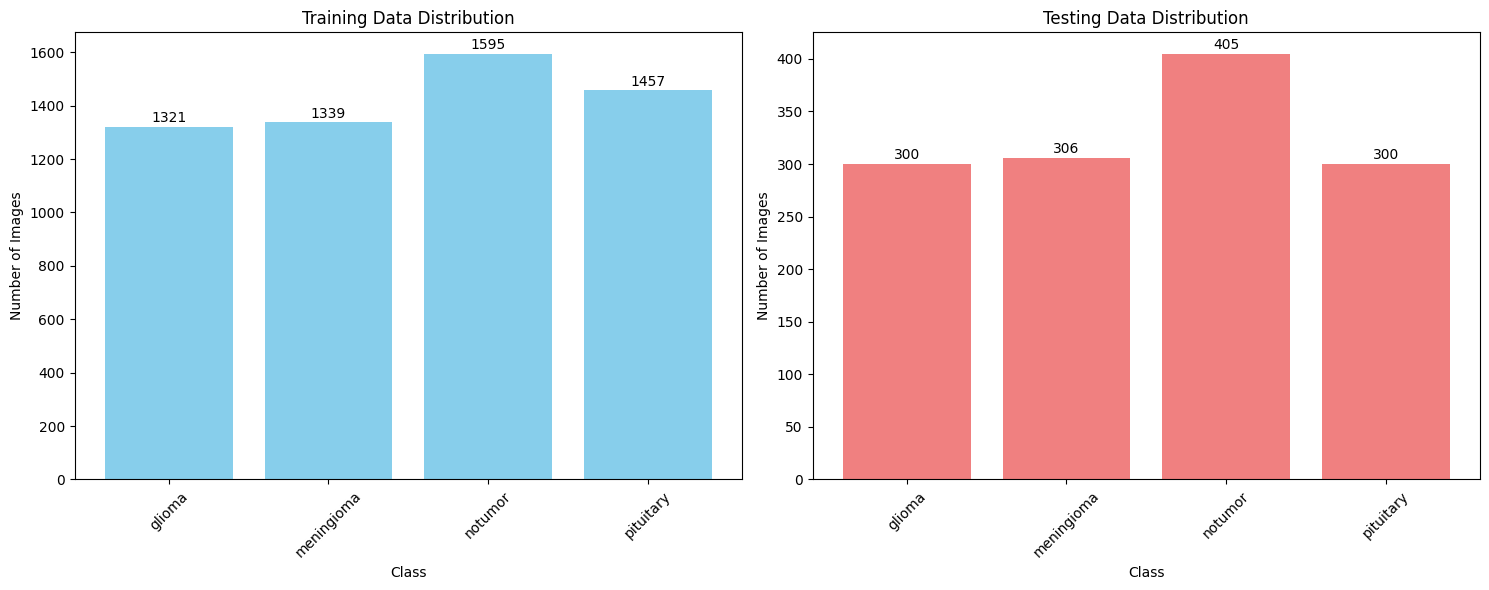

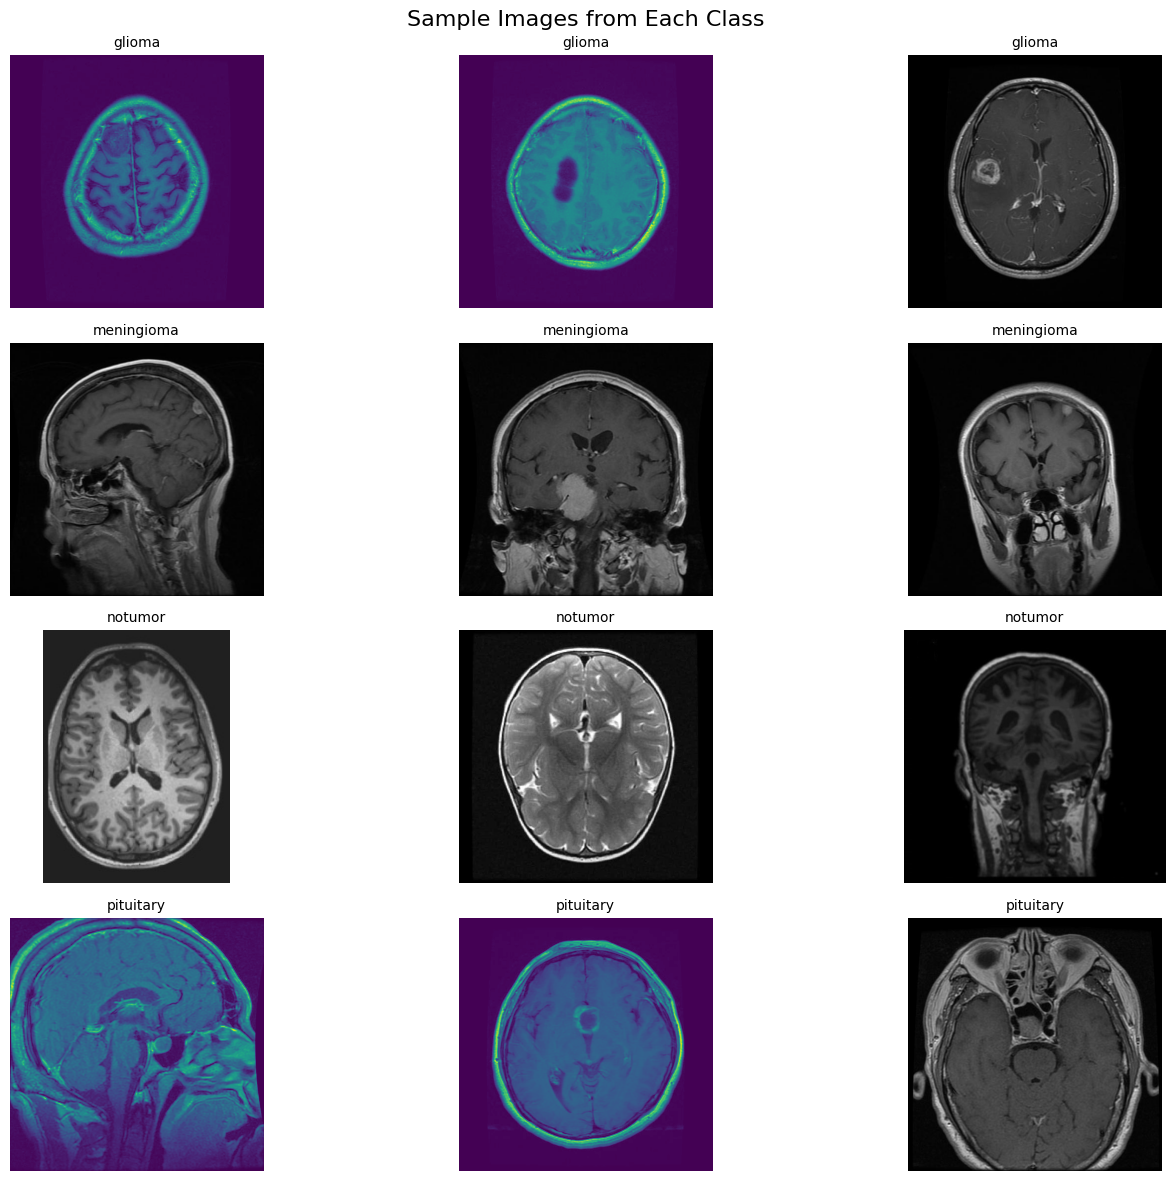

✅ Dataset analysis completed!


In [3]:
def analyze_dataset():
    """
    Analyze and visualize the dataset distribution
    """
    # Define dataset paths
    train_dir = '/DEEPAK/Me_projects/Major_project/Brain_Tumor_detection/Final_project/data_set/Training'
    test_dir = '/DEEPAK/Me_projects/Major_project/Brain_Tumor_detection/Final_project/data_set/Testing'
    
    # Check if directories exist
    if not os.path.exists(train_dir) or not os.path.exists(test_dir):
        print(f"❌ Error: Dataset directories not found!")
        print(f"Training directory: {train_dir}")
        print(f"Testing directory: {test_dir}")
        return None, None
    
    # Get class names
    class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
    print(f"✅ Found classes: {class_names}")
    
    # Count images in each class for training and testing
    train_counts = {}
    test_counts = {}
    
    for class_name in class_names:
        train_path = os.path.join(train_dir, class_name)
        test_path = os.path.join(test_dir, class_name)
        
        train_counts[class_name] = len([f for f in os.listdir(train_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
        test_counts[class_name] = len([f for f in os.listdir(test_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
    
    # Plot dataset distribution
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Training data distribution
    ax1.bar(train_counts.keys(), train_counts.values(), color='skyblue')
    ax1.set_title('Training Data Distribution')
    ax1.set_xlabel('Class')
    ax1.set_ylabel('Number of Images')
    ax1.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for i, v in enumerate(train_counts.values()):
        ax1.text(i, v + 5, str(v), ha='center', va='bottom')
    
    # Testing data distribution
    ax2.bar(test_counts.keys(), test_counts.values(), color='lightcoral')
    ax2.set_title('Testing Data Distribution')
    ax2.set_xlabel('Class')
    ax2.set_ylabel('Number of Images')
    ax2.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for i, v in enumerate(test_counts.values()):
        ax2.text(i, v + 2, str(v), ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig('evaluation/dataset_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Display sample images from each class
    display_sample_images(train_dir, class_names)
    
    return class_names, train_counts, test_counts

def display_sample_images(data_dir, class_names, num_samples=3):
    """
    Display sample images from each class
    """
    fig, axes = plt.subplots(len(class_names), num_samples, figsize=(15, 12))
    
    for i, class_name in enumerate(class_names):
        class_path = os.path.join(data_dir, class_name)
        images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
        
        # Select random samples
        sample_images = random.sample(images, min(num_samples, len(images)))
        
        for j, img_name in enumerate(sample_images):
            img_path = os.path.join(class_path, img_name)
            img = Image.open(img_path)
            
            if len(class_names) > 1:
                axes[i, j].imshow(img)
                axes[i, j].set_title(f'{class_name}', fontsize=10)
                axes[i, j].axis('off')
                
                # Save sample images for GUI
                if j == 0:
                    save_path = f'sample_images/{class_name}_sample.jpg'
                    img.save(save_path)
            else:
                axes[j].imshow(img)
                axes[j].set_title(f'{class_name}', fontsize=10)
                axes[j].axis('off')
    
    plt.suptitle('Sample Images from Each Class', fontsize=16)
    plt.tight_layout()
    plt.savefig('evaluation/sample_images.png', dpi=300, bbox_inches='tight')
    plt.show()

# Run dataset analysis
print("🔍 Analyzing dataset...")
class_names, train_counts, test_counts = analyze_dataset()
print("✅ Dataset analysis completed!")

#### Model Creation Function

In [4]:
def create_enhanced_model(input_shape=(224, 224, 3)):
    """
    Create an enhanced CNN model with improved architecture
    """
    model = Sequential()
    
    # First Convolutional Block
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))
    model.add(Dropout(0.2))
    
    # Second Convolutional Block
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))
    model.add(Dropout(0.2))
    
    # Third Convolutional Block
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))
    model.add(Dropout(0.3))
    
    # Fourth Convolutional Block
    model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))
    model.add(Dropout(0.3))
    
    # Fifth Convolutional Block
    model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))
    model.add(Dropout(0.4))
    
    # Flatten and Dense Layers
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    
    # Output Layer
    model.add(Dense(4, activation='softmax'))  # 4 classes: glioma, meningioma, notumor, pituitary
    
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy', 
                           tf.keras.metrics.Precision(name='precision'),
                           tf.keras.metrics.Recall(name='recall'),
                           tf.keras.metrics.F1Score(name='f1_score', average='weighted')])
    
    return model

print("🧠 Creating model architecture...")
model = create_enhanced_model()
model.summary()
print("✅ Model created successfully!")

🧠 Creating model architecture...


C:\Program Files\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 224, 224, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 112, 112, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 56, 56, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 17,701,156 (67.52 MB)

 Trainable params: 17,695,652 (67.50 MB)

 Non-trainable params: 5,504 (21.50 KB)

✅ Model created successfully!


#### Data Generator Preparation

In [5]:
def prepare_data_generators():
    """
    Prepare data generators for training, validation, and testing
    Returns the generators and class names
    """
    # Define dataset paths
    train_dir = '/DEEPAK/Me_projects/Major_project/Brain tumor detection/Final_project/data_set/Training'
    test_dir = '/DEEPAK/Me_projects/Major_project/Brain tumor detection/Final_project/data_set/Testing'
    
    # Check if directories exist
    if not os.path.exists(train_dir) or not os.path.exists(test_dir):
        print(f"❌ Error: Dataset directories not found!")
        print(f"Training directory: {train_dir}")
        print(f"Testing directory: {test_dir}")
        return None, None, None, None
    
    # Get class names
    class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
    print(f"✅ Found classes: {class_names}")
    
    # Enhanced Data generators with more augmentation
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.3,
        horizontal_flip=True,
        vertical_flip=True,
        brightness_range=[0.8, 1.2],
        fill_mode='nearest',
        validation_split=0.2
    )
    
    test_datagen = ImageDataGenerator(rescale=1./255)
    
    # Create separate generators for training and validation
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical',
        subset='training',
        shuffle=True,
        classes=class_names
    )
    
    validation_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical',
        subset='validation',
        shuffle=False,
        classes=class_names
    )
    
    # Create test generator from Testing directory
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical',
        shuffle=False,
        classes=class_names
    )
    
    # Save the class indices for prediction
    class_indices = train_generator.class_indices
    with open('models/class_indices.pkl', 'wb') as f:
        pickle.dump(class_indices, f)
    
    # Check if generators found images
    print(f"✅ Training images found: {train_generator.samples}")
    print(f"✅ Validation images found: {validation_generator.samples}")
    print(f"✅ Test images found: {test_generator.samples}")
    
    # If validation or test generators found 0 images, handle the error
    if validation_generator.samples == 0 or test_generator.samples == 0:
        print("❌ Error: No images found in validation or test sets!")
        print("Please check your dataset structure:")
        print("- Training images should be in 'dataset/Training/class_name/*.jpg'")
        print("- Testing images should be in 'dataset/Testing/class_name/*.jpg'")
        print("- Make sure each class has its own subdirectory")
        return None, None, None, None
    
    return train_generator, validation_generator, test_generator, class_names

print("📊 Preparing data generators...")
train_generator, validation_generator, test_generator, class_names = prepare_data_generators()
print("✅ Data generators prepared successfully!")

📊 Preparing data generators...
✅ Found classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
✅ Training images found: 4571
✅ Validation images found: 1141
✅ Test images found: 1311
✅ Data generators prepared successfully!


#### Model Training

In [8]:
def train_model():
    """
    Train the model and save training history
    """
    model_path = 'models/brain_tumor_model.h5'
    history_path = 'models/training_history.pkl'
    
    # Check if model already exists
    if os.path.exists(model_path) and os.path.exists(history_path):
        print("✅ Pre-trained model found. Skipping training.")
        return
    
    # Create model
    model = create_enhanced_model()
    
    # Callbacks (checkpoints must use .keras in Keras 3.x)
    early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001, verbose=1)
    checkpoint = ModelCheckpoint(
        filepath='models/best_model.keras',   # 👈 must be .keras
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
    
    # Train the model
    print("🎯 Training the model...")
    history = model.fit(
        train_generator,
        epochs=50,
        validation_data=validation_generator,
        callbacks=[early_stop, reduce_lr, checkpoint],
        verbose=1
    )
    
    # Load the best model (from .keras checkpoint)
    best_model = load_model('models/best_model.keras')
    
    # Save final model in .h5 format for compatibility
    best_model.save(model_path)   # 👈 saves as .h5 if filename ends with .h5
    
    # Save training history
    with open(history_path, 'wb') as f:
        pickle.dump(history.history, f)
    
    print(f"✅ Model training completed and saved to {model_path}")

print("🚀 Starting model training...")
train_model()
print("✅ Model training completed!")


🚀 Starting model training...
🎯 Training the model...


C:\Program Files\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.4099 - f1_score: 0.4138 - loss: 1.7467 - precision: 0.4320 - recall: 0.3576 
Epoch 1: val_accuracy improved from -inf to 0.23138, saving model to models/best_model.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 2215s 15s/step - accuracy: 0.4102 - f1_score: 0.4142 - loss: 1.7457 - precision: 0.4324 - recall: 0.3579 - val_accuracy: 0.2314 - val_f1_score: 0.0870 - val_loss: 3.9306 - val_precision: 0.2314 - val_recall: 0.2314 - learning_rate: 1.0000e-04
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.5030 - f1_score: 0.5080 - loss: 1.3750 - precision: 0.5379 - recall: 0.4417 
Epoch 2: val_accuracy did not improve from 0.23138
143/143 ━━━━━━━━━━━━━━━━━━━━ 2550s 18s/step - accuracy: 0.5030 - f1_score: 0.5080 - loss: 1.3747 - precision: 0.5380 - recall: 0.4417 - val_accuracy: 0.2314 - val_f1_score: 0.0870 - val_loss: 2.8075 - val_precision: 0.2391 - val_recall: 0.2314 - learning_rate: 1.0000e-04
Epoch 3/50
143/143 ━━━━━━━

✅ Model training completed and saved to models/brain_tumor_model.h5
✅ Model training completed!


#### Training Visualization

📈 Plotting training history...


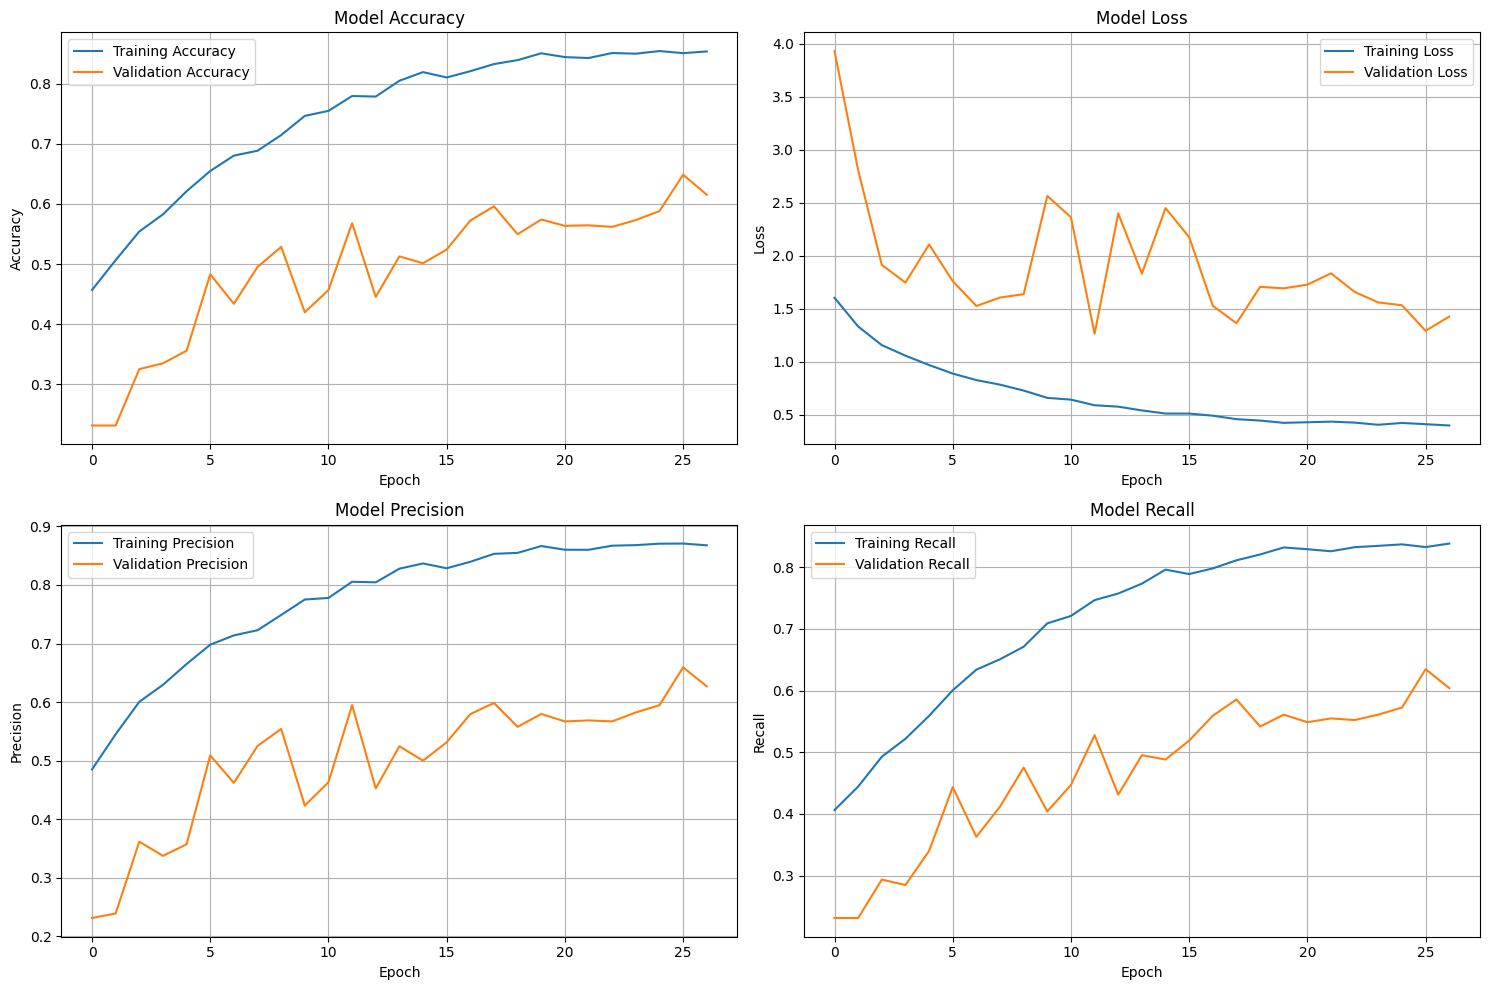

🌟 Best Validation Accuracy: 0.6486 at epoch 26
✅ Training history plotted!


In [10]:
def plot_training_history():
    """
    Plot training history (accuracy and loss curves)
    """
    history_path = 'models/training_history.pkl'
    
    if not os.path.exists(history_path):
        print("❌ Training history not found. Please train the model first.")
        return
    
    with open(history_path, 'rb') as f:
        history = pickle.load(f)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot accuracy
    axes[0, 0].plot(history['accuracy'], label='Training Accuracy')
    axes[0, 0].plot(history['val_accuracy'], label='Validation Accuracy')
    axes[0, 0].set_title('Model Accuracy')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # Plot loss
    axes[0, 1].plot(history['loss'], label='Training Loss')
    axes[0, 1].plot(history['val_loss'], label='Validation Loss')
    axes[0, 1].set_title('Model Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # Plot precision
    if 'precision' in history:
        axes[1, 0].plot(history['precision'], label='Training Precision')
        axes[1, 0].plot(history['val_precision'], label='Validation Precision')
        axes[1, 0].set_title('Model Precision')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Precision')
        axes[1, 0].legend()
        axes[1, 0].grid(True)
    
    # Plot recall
    if 'recall' in history:
        axes[1, 1].plot(history['recall'], label='Training Recall')
        axes[1, 1].plot(history['val_recall'], label='Validation Recall')
        axes[1, 1].set_title('Model Recall')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Recall')
        axes[1, 1].legend()
        axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.savefig('training_history/training_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Highlight best accuracy
    if 'val_accuracy' in history:
        best_val_accuracy = max(history['val_accuracy'])
        best_epoch = history['val_accuracy'].index(best_val_accuracy) + 1
        print(f"🌟 Best Validation Accuracy: {best_val_accuracy:.4f} at epoch {best_epoch}")

print("📈 Plotting training history...")
plot_training_history()
print("✅ Training history plotted!")

#### Model Evaluation

🧪 Evaluating model performance...


✅ Found classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
✅ Training images found: 4571
✅ Validation images found: 1141
✅ Test images found: 1311


C:\Program Files\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


41/41 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.5652 - f1_score: 0.6439 - loss: 2.0515 - precision: 0.5718 - recall: 0.5621
📊 MODEL PERFORMANCE METRICS
Test Accuracy: 0.6545
Test Precision: 0.6607
Test Recall: 0.6506
Test F1-Score: 0.6322
41/41 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step


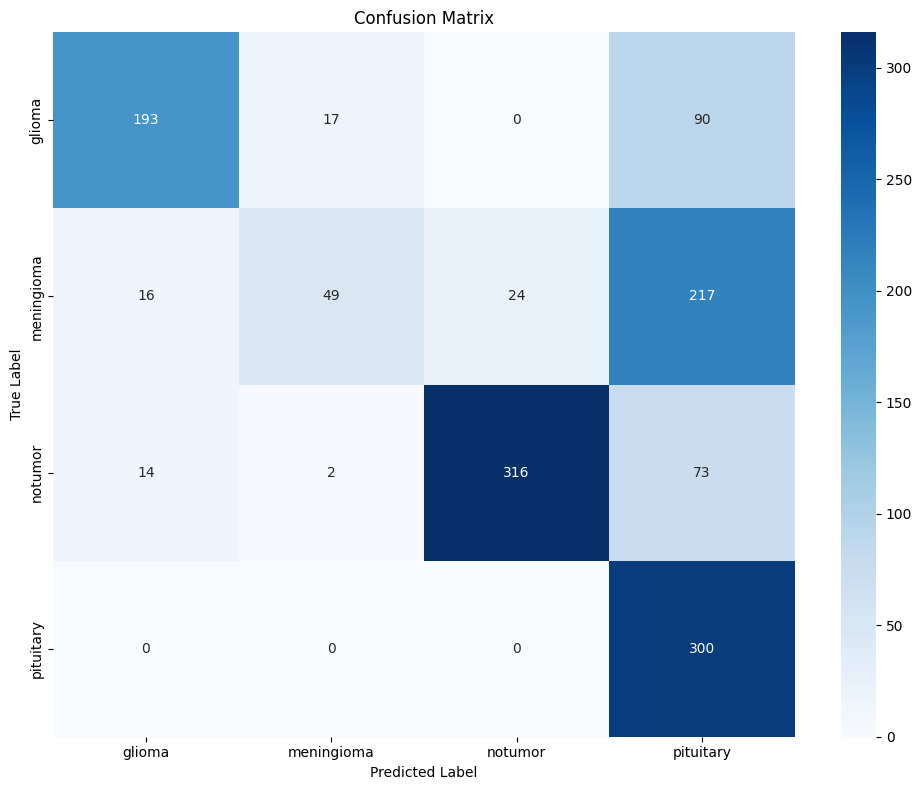

📝 Classification Report:
              precision    recall  f1-score   support

      glioma       0.87      0.64      0.74       300
  meningioma       0.72      0.16      0.26       306
     notumor       0.93      0.78      0.85       405
   pituitary       0.44      1.00      0.61       300

    accuracy                           0.65      1311
   macro avg       0.74      0.65      0.62      1311
weighted avg       0.75      0.65      0.63      1311



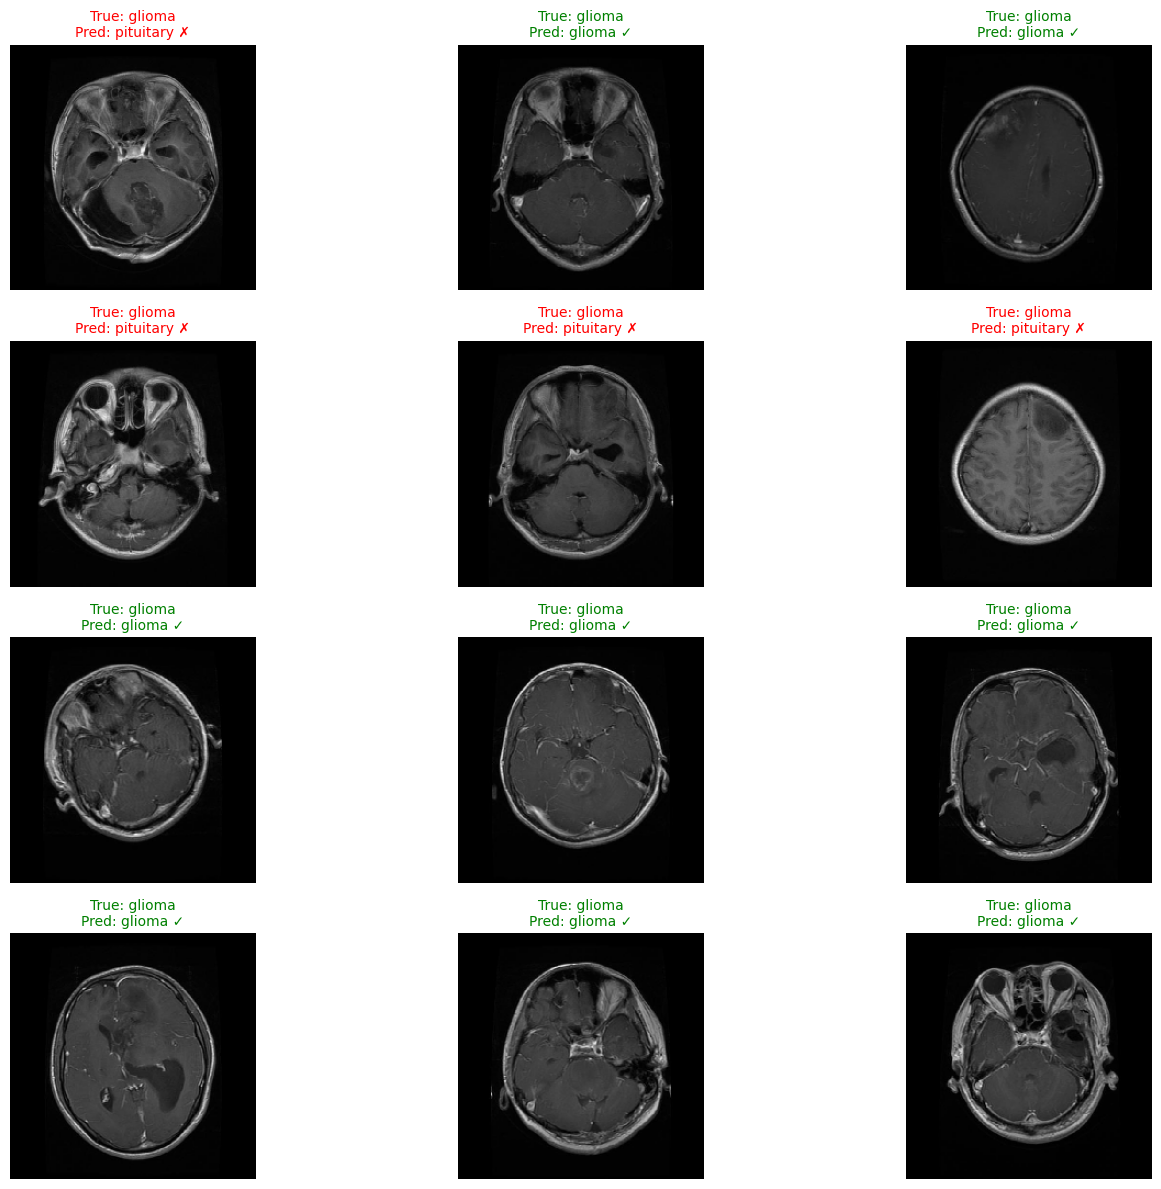

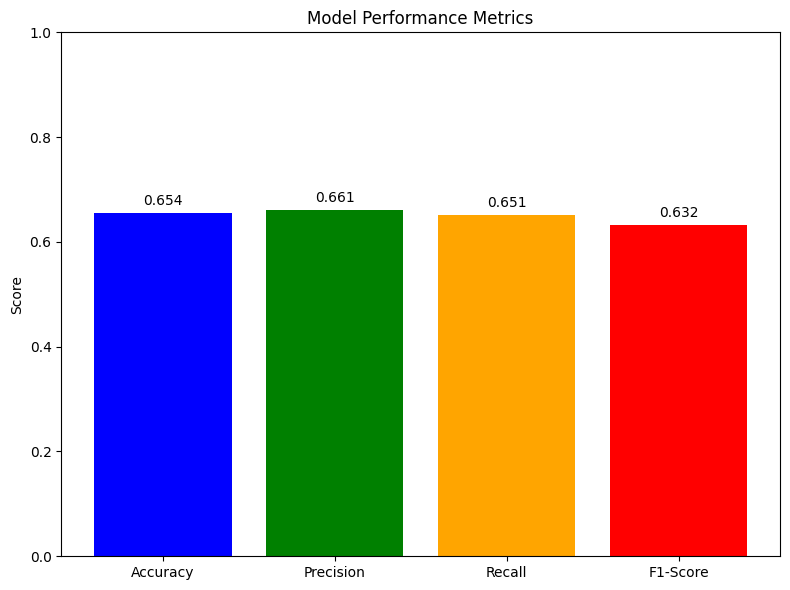

✅ Model evaluation completed! Accuracy: 0.6545


In [11]:
def evaluate_model():
    """
    Evaluate the trained model on test data
    """
    model_path = 'models/brain_tumor_model.h5'
    
    if not os.path.exists(model_path):
        print("❌ Model not found. Please train the model first.")
        return None, None, None, None
    
    # Load the model
    model = load_model(model_path)
    
    # Prepare data generators
    _, _, test_generator, class_names = prepare_data_generators()
    if test_generator is None:
        return None, None, None, None
    
    # Evaluate on test set
    test_results = model.evaluate(test_generator)
    test_loss, test_accuracy, test_precision, test_recall, test_f1 = test_results
    
    print("=" * 60)
    print("📊 MODEL PERFORMANCE METRICS")
    print("=" * 60)
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test Precision: {test_precision:.4f}")
    print(f"Test Recall: {test_recall:.4f}")
    print(f"Test F1-Score: {test_f1:.4f}")
    print("=" * 60)
    
    # Generate predictions for detailed analysis
    test_generator.reset()
    predictions = model.predict(test_generator, verbose=1)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = test_generator.classes
    
    # Generate confusion matrix
    cm = confusion_matrix(true_classes, predicted_classes)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('evaluation/confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Generate and save classification report
    report = classification_report(true_classes, predicted_classes, target_names=class_names)
    with open('evaluation/classification_report.txt', 'w') as f:
        f.write(report)
    
    print("📝 Classification Report:")
    print(report)
    
    # Plot sample predictions
    plot_sample_predictions(model, test_generator, class_names)
    
    # Create a performance summary DataFrame
    performance_data = {
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
        'Value': [test_accuracy, test_precision, test_recall, test_f1]
    }
    
    performance_df = pd.DataFrame(performance_data)
    performance_df.to_csv('evaluation/performance_summary.csv', index=False)
    
    # Plot performance metrics
    plt.figure(figsize=(8, 6))
    bars = plt.bar(performance_df['Metric'], performance_df['Value'], color=['blue', 'green', 'orange', 'red'])
    plt.title('Model Performance Metrics')
    plt.ylabel('Score')
    plt.ylim(0, 1)
    
    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig('evaluation/performance_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return test_accuracy, test_precision, test_recall, test_f1

def plot_sample_predictions(model, test_generator, class_names, num_samples=12):
    """
    Plot sample predictions with true vs predicted labels
    """
    test_generator.reset()
    x, y = next(test_generator)
    
    # Get predictions
    predictions = model.predict(x, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = np.argmax(y, axis=1)
    
    # Create a grid of sample images
    plt.figure(figsize=(15, 12))
    for i in range(min(num_samples, len(x))):
        plt.subplot(4, 3, i+1)
        plt.imshow(x[i])
        
        # Determine text color based on correct prediction
        if predicted_classes[i] == true_classes[i]:
            text_color = 'green'
            result = "✓"
        else:
            text_color = 'red'
            result = "✗"
            
        plt.title(f"True: {class_names[true_classes[i]]}\nPred: {class_names[predicted_classes[i]]} {result}", 
                 color=text_color, fontsize=10)
        plt.axis('off')
    
    plt.tight_layout()
    plt.savefig('evaluation/sample_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()

print("🧪 Evaluating model performance...")
accuracy, precision, recall, f1 = evaluate_model()
if accuracy is not None:
    print(f"✅ Model evaluation completed! Accuracy: {accuracy:.4f}")

#### GUI Interface with Gradio

In [22]:
def create_gui():
    """
    Create a Gradio interface for model inference
    """
    model_path = 'models/brain_tumor_model.h5'
    
    if not os.path.exists(model_path):
        print("❌ Model not found. Please train the model first.")
        return
    
    # Load the model and class indices
    model = load_model(model_path)
    
    with open('models/class_indices.pkl', 'rb') as f:
        class_indices = pickle.load(f)
    
    class_names = list(class_indices.keys())
    
    def predict_image(image):
        """
        Predict the class of an input image
        """
        # Preprocess the image
        image = image.resize((224, 224))
        img_array = np.array(image) / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        
        # Make prediction
        predictions = model.predict(img_array, verbose=0)
        predicted_class = class_names[np.argmax(predictions)]
        confidence = np.max(predictions)
        
        # Create a bar chart of predictions
        fig, ax = plt.subplots(figsize=(8, 6))
        y_pos = np.arange(len(class_names))
        ax.barh(y_pos, predictions[0], color='skyblue')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(class_names)
        ax.invert_yaxis()
        ax.set_xlabel('Confidence')
        ax.set_title('Prediction Confidence')
        
        # Add confidence values to bars
        for i, v in enumerate(predictions[0]):
            ax.text(v + 0.01, i, f'{v:.3f}', color='black', va='center')
        
        plt.tight_layout()
        
        return predicted_class, confidence, fig
    
    # Create custom CSS for light gray background
    custom_css = """
    .gradio-container {
        background-color: #f0f0f0;
    }
    .disclaimer-box {
        background-color: #ffe6e6;
        padding: 15px;
        border-radius: 10px;
        border-left: 5px solid #ff0000;
        margin-bottom: 20px;
    }
    """
    
    # Create Gradio interface with custom theme
    with gr.Blocks(title="Brain Tumor Detection", theme=gr.themes.Soft(), css=custom_css) as demo:
        gr.Markdown("# 🧠 Brain Tumor Detection")
        gr.Markdown("Upload an MRI image to classify it into one of the following categories: glioma, meningioma, notumor, or pituitary.")
        
        # Add important disclaimer
        with gr.Row():
            with gr.Column():
                gr.Markdown("""
                <div class="disclaimer-box">
                <h3>⚠️ Important Note</h3>
                <p>This project is a prototype developed for learning purposes only and should not be used as a substitute for professional medical advice—always consult a qualified doctor for diagnosis and treatment.</p>
                </div>
                """)
        
        with gr.Row():
            with gr.Column():
                image_input = gr.Image(type="pil", label="Upload MRI Image")
                submit_btn = gr.Button("Analyze Image", variant="primary")
            
            with gr.Column():
                label_output = gr.Label(label="Prediction")
                confidence_output = gr.Number(label="Confidence", precision=3)
                plot_output = gr.Plot(label="Confidence Distribution")
        
        # Add sample images
        gr.Markdown("## Sample Images")
        sample_images = []
        
        for class_name in class_names:
            sample_path = f"sample_images/{class_name}_sample.jpg"
            if os.path.exists(sample_path):
                sample_images.append((sample_path, class_name))  # Store as (image, caption) tuple
        
        if sample_images:
            gr.Gallery(value=sample_images, label="Sample Images", columns=4, height="auto")
        
        # Set up event handling
        submit_btn.click(
            fn=predict_image,
            inputs=image_input,
            outputs=[label_output, confidence_output, plot_output]
        )
    
    return demo

print("🖥️ Creating GUI interface...")
gui = create_gui()
print("✅ GUI created successfully!")
print("\n🎉 To launch the GUI, run: gui.launch(share=True)")

🖥️ Creating GUI interface...


✅ GUI created successfully!

🎉 To launch the GUI, run: gui.launch(share=True)


In [25]:
# Running the GUI

gui.launch(share=True)

Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


#### GUI Interface with Gradio

In [1]:
# Cell 8: GUI Interface with Gradio
import os
import socket
import pickle
import numpy as np
import matplotlib.pyplot as plt
import gradio as gr
from contextlib import closing
from tensorflow.keras.models import load_model

def find_available_port(start_port=7860, max_attempts=20):
    """Find an available port starting from the given port number"""
    for port in range(start_port, start_port + max_attempts):
        with closing(socket.socket(socket.AF_INET, socket.SOCK_STREAM)) as sock:
            try:
                sock.bind(('localhost', port))
                return port
            except OSError:
                continue
    return None

def create_gui():
    """
    Create a Gradio interface for model inference
    """
    model_path = 'models/brain_tumor_model.h5'
    
    if not os.path.exists(model_path):
        print("❌ Model not found. Please train the model first.")
        return
    
    # Load the model and class indices
    model = load_model(model_path)
    
    with open('models/class_indices.pkl', 'rb') as f:
        class_indices = pickle.load(f)
    
    class_names = list(class_indices.keys())
    
    def predict_image(image):
        """
        Predict the class of an input image
        """
        # Preprocess the image
        image = image.resize((224, 224))
        img_array = np.array(image) / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        
        # Make prediction
        predictions = model.predict(img_array, verbose=0)
        predicted_class = class_names[np.argmax(predictions)]
        confidence = np.max(predictions)
        
        # Create a bar chart of predictions
        fig, ax = plt.subplots(figsize=(8, 6))
        y_pos = np.arange(len(class_names))
        ax.barh(y_pos, predictions[0], color='skyblue')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(class_names)
        ax.invert_yaxis()
        ax.set_xlabel('Confidence')
        ax.set_title('Prediction Confidence')
        
        # Add confidence values to bars
        for i, v in enumerate(predictions[0]):
            ax.text(v + 0.01, i, f'{v:.3f}', color='black', va='center')
        
        plt.tight_layout()
        
        return predicted_class, confidence, fig
    
    # Create custom CSS for light gray background
    custom_css = """
    .gradio-container {
        background-color: #f0f0f0;
    }
    .disclaimer-box {
        background-color: #ffe6e6;
        padding: 15px;
        border-radius: 10px;
        border-left: 5px solid #ff0000;
        margin-bottom: 20px;
    }
    """
    
    # Create Gradio interface with custom theme
    with gr.Blocks(title="Brain Tumor Detection", theme=gr.themes.Soft(), css=custom_css) as demo:
        gr.Markdown("# 🧠 Brain Tumor Detection")
        gr.Markdown("Upload an MRI image to classify it into one of the following categories: glioma, meningioma, notumor, or pituitary.")
        
        # Add important disclaimer
        with gr.Row():
            with gr.Column():
                gr.Markdown("""
                <div class="disclaimer-box">
                <h3>⚠️ Important Note</h3>
                <p>This project is a prototype developed for learning purposes only and should not be used as a substitute for professional medical advice—always consult a qualified doctor for diagnosis and treatment.</p>
                </div>
                """)
        
        with gr.Row():
            with gr.Column():
                image_input = gr.Image(type="pil", label="Upload MRI Image")
                submit_btn = gr.Button("Analyze Image", variant="primary")
            
            with gr.Column():
                label_output = gr.Label(label="Prediction")
                confidence_output = gr.Number(label="Confidence", precision=3)
                plot_output = gr.Plot(label="Confidence Distribution")
        
        # Add sample images
        gr.Markdown("## Sample Images")
        sample_images = []
        
        for class_name in class_names:
            sample_path = f"sample_images/{class_name}_sample.jpg"
            if os.path.exists(sample_path):
                sample_images.append((sample_path, class_name))  # Store as (image, caption) tuple
        
        if sample_images:
            gr.Gallery(value=sample_images, label="Sample Images", columns=4, height="auto")
        
        # Set up event handling
        submit_btn.click(
            fn=predict_image,
            inputs=image_input,
            outputs=[label_output, confidence_output, plot_output]
        )
    
    return demo

# Find an available port
port = find_available_port(7860, 50)
if port is None:
    print("❌ Could not find an available port. Please close other Gradio instances and try again.")
else:
    print(f"🖥️ Creating GUI interface...")
    gui = create_gui()
    print("✅ GUI created successfully!")
    print(f"\n🎉 Launching the GUI on port {port}...")
    gui.launch(server_port=port, share=True)

🖥️ Creating GUI interface...


✅ GUI created successfully!

🎉 Launching the GUI on port 7860...
* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


Traceback (most recent call last):
  File "C:\Program Files\Python312\Lib\site-packages\gradio\queueing.py", line 745, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\Python312\Lib\site-packages\gradio\route_utils.py", line 353, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\Python312\Lib\site-packages\gradio\blocks.py", line 2116, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\Python312\Lib\site-packages\gradio\blocks.py", line 1623, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\Python312\Lib\site-packages\anyio\to_thread.py", line 33, in run_sync
    return await get_async_backend().run_sync_in_worker